###

**A. 가입 1년미만(12개월) 고객의 이탈율이 평균의 두배 이상임**

전체 이탈률: 0.30166

신규(<=12m) 고객수: 3199

신규(<=12m) 이탈률: 0.6245701781806815


**B. complain_flag 있으면 churn_flag(확율 20%이상) 올라감**

**C. 최근 12개월 고객 컨택(문의) 횟수 는 1~8번까지는 큰 의미는 없었으나, 9번이상부터는 해지비율 폭증 함**



In [25]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# insurance_df = pd.read_csv('./data/insurance_policyholder_churn_synthetic.csv')
# insurance_df.head()
# insurance_df.info()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

# 1) Load
df = pd.read_csv('../data/insurance_policyholder_churn_synthetic.csv')

# 2) 신규 고객군(<=12개월)
new = df[df["customer_tenure_months"] <= 12].copy()

# 핵심 수치
overall_rate = df["churn_flag"].mean()
new_rate = new["churn_flag"].mean()
print("전체 이탈률:", overall_rate)
print("신규(<=12m) 고객수:", len(new))
print("신규(<=12m) 이탈률:", new_rate)

# 3) EDA: tenure 구간별 이탈률
tenure_bins = pd.cut(
    df["customer_tenure_months"],
    bins=[0, 12, 24, 36, 60, 120, 999],
    include_lowest=True
)
tenure_churn = df.groupby(tenure_bins)["churn_flag"].mean()
print("\n[tenure 구간별 이탈률]")
print(tenure_churn)

# 4) EDA: renewal_month별(신규군) 이탈률
renew_new = new.groupby("renewal_month")["churn_flag"].mean()
print("\n[renewal_month별 신규군 이탈률]")
print(renew_new)

# 5) 모델 학습용 피처 (누수/ID 제거)
drop_cols = ["customer_id", "as_of_date", "churn_flag", "churn_type", "churn_probability_true"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = new[feature_cols].copy()
y = new["churn_flag"].copy()

numeric = [c for c in X.columns if X[c].dtype != "object"]
categorical = [c for c in X.columns if X[c].dtype == "object"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

log_clf = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=5000)),
])

rf_clf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=2,
        class_weight="balanced_subsample",
        min_samples_leaf=2
    )),
])

log_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

def eval_model(clf, X_test, y_test):
    proba = clf.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    out = {
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "cm": confusion_matrix(y_test, pred),
    }
    return out

print("\n[LogisticRegression]")
print(eval_model(log_clf, X_test, y_test))

print("\n[RandomForest]")
print(eval_model(rf_clf, X_test, y_test))

# 6) RF 중요도(불순도 기반)
feat_names = rf_clf.named_steps["prep"].get_feature_names_out()
importances = rf_clf.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False)

print("\n[RF 중요도 TOP15]")
print(imp_df.head(15))

# 7) SHAP (설치되어 있지 않으면: pip install shap)

import shap
import scipy.sparse as sp

X_test_t = rf_clf.named_steps["prep"].transform(X_test)
idx = np.random.RandomState(42).choice(X_test_t.shape[0], size=min(300, X_test_t.shape[0]), replace=False)
X_sample = X_test_t[idx]
X_sample = X_sample.toarray() if sp.issparse(X_sample) else X_sample

explainer = shap.TreeExplainer(rf_clf.named_steps["model"])
sv = explainer.shap_values(X_sample)

# sklearn RF에서 (n, features, 2) 형태로 나와서 class=1만 선택
sv1 = sv[:, :, 1]
mean_abs = np.abs(sv1).mean(axis=0)

shap_imp = (
    pd.DataFrame({"feature": feat_names, "mean_abs_shap": mean_abs})
      .sort_values("mean_abs_shap", ascending=False)
)

print("\n[SHAP 글로벌 TOP15]")
print(shap_imp.head(15))




전체 이탈률: 0.30166
신규(<=12m) 고객수: 3199
신규(<=12m) 이탈률: 0.6245701781806815

[tenure 구간별 이탈률]
customer_tenure_months
(-0.001, 12.0]    0.624570
(12.0, 24.0]      0.390821
(24.0, 36.0]      0.326338
(36.0, 60.0]      0.302118
(60.0, 120.0]     0.264824
(120.0, 999.0]    0.252889
Name: churn_flag, dtype: float64

[renewal_month별 신규군 이탈률]
renewal_month
1     0.678414
2     0.656250
3     0.599237
4     0.639098
5     0.614545
6     0.618421
7     0.594406
8     0.647260
9     0.602996
10    0.652510
11    0.576923
12    0.624490
Name: churn_flag, dtype: float64


C:\Users\monda\AppData\Local\Temp\ipykernel_157148\490255749.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby(tenure_bins)["churn_flag"].mean()



[LogisticRegression]
{'roc_auc': 0.8259266666666667, 'pr_auc': 0.8796708124136275, 'accuracy': 0.75375, 'precision': 0.7831775700934579, 'recall': 0.838, 'f1': 0.8096618357487922, 'cm': array([[184, 116],
       [ 81, 419]])}

[RandomForest]
{'roc_auc': 0.8677733333333333, 'pr_auc': 0.9080603602210877, 'accuracy': 0.79875, 'precision': 0.834319526627219, 'recall': 0.846, 'f1': 0.8401191658391262, 'cm': array([[216,  84],
       [ 77, 423]])}

[RF 중요도 TOP15]
                             feature  importance
7            num__premium_change_pct    0.358995
6             num__premium_last_year    0.043321
1        num__customer_tenure_months    0.043093
5               num__current_premium    0.041285
24        num__days_since_last_claim    0.039080
19             num__avg_claim_amount    0.037372
0                           num__age    0.037028
10    num__premium_to_coverage_ratio    0.035591
9               num__coverage_amount    0.035310
23     num__avg_settlement_time_days    0.03331

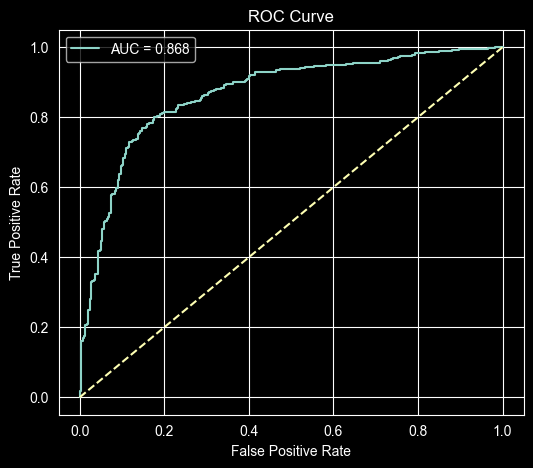

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = rf_clf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

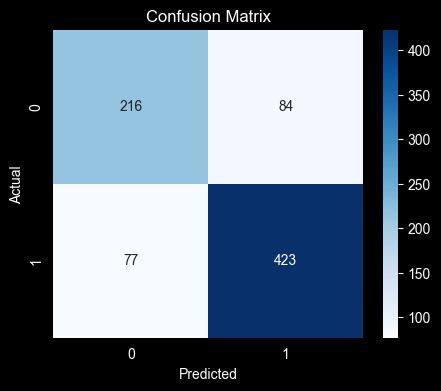

In [30]:
from sklearn.metrics import confusion_matrix

y_pred = rf_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

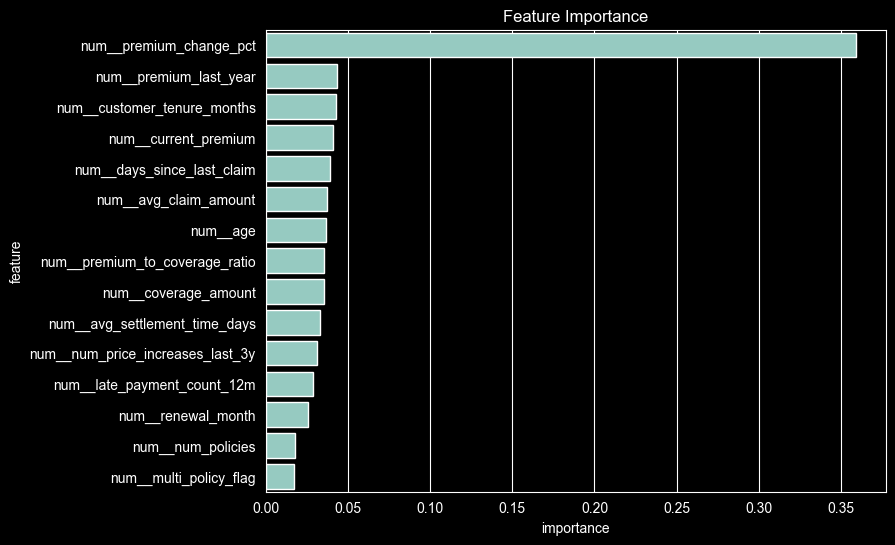

In [31]:
feature_names = rf_clf.named_steps['prep'].get_feature_names_out()

importances = rf_clf.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(
    data=importance_df,
    y="feature",
    x="importance"
)

plt.title("Feature Importance")
plt.show()

In [32]:
# import shap
#
# X_test_trans = rf_clf.named_steps["prep"].transform(X_test)
#
# explainer = shap.TreeExplainer(rf_clf.named_steps["model"])
#
# shap_values = explainer.shap_values(X_test_trans)
#
# shap.summary_plot(
#     shap_values[1],
#     X_test_trans,
#     feature_names=feature_names
# )

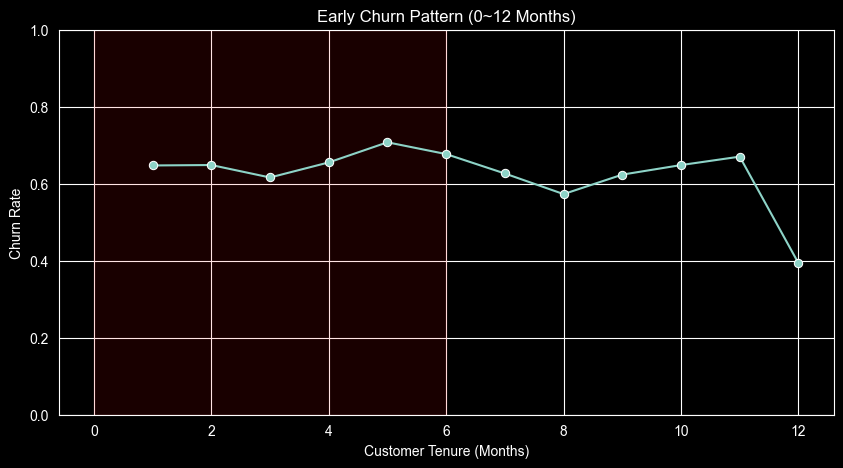

<Axes: xlabel='customer_tenure_months', ylabel='churn_flag'>

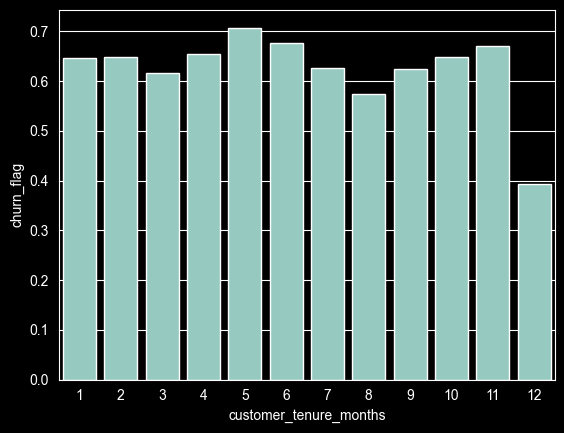

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tenure_churn = df.groupby('customer_tenure_months')['churn_flag'].mean().reset_index()

early_churn = tenure_churn[tenure_churn['customer_tenure_months'] <= 12]

plt.figure(figsize=(10,5))

sns.lineplot(
data=early_churn,
x='customer_tenure_months',
y='churn_flag',
marker='o'
)

plt.axvspan(0,6,color='red',alpha=0.1)

plt.title('Early Churn Pattern (0~12 Months)')
plt.xlabel('Customer Tenure (Months)')
plt.ylabel('Churn Rate')

plt.ylim(0,1)

plt.show()

sns.barplot(
data=early_churn,
x='customer_tenure_months',
y='churn_flag'
)

In [1]:
support_churn = df.groupby('complaint_flag')['churn_flag'].mean().reset_index()

# barplot이 관계를 보기 가장 좋다.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
data=support_churn,
x='complaint_flag',
y='churn_flag'
)

plt.title("churn_flag Rate by complaint_flag")
plt.xlabel("Number of complaint_flag")
plt.ylabel("churn_flag Rate")

plt.show()

plt.figure(figsize=(8,5))

sns.regplot(
data=df,
x='complaint_flag',
y='churn_flag',
logistic=True
)

plt.title("Relationship Between complaint_flag and churn_flag")

plt.show()

# 설명

logistic=True


NameError: name 'df' is not defined

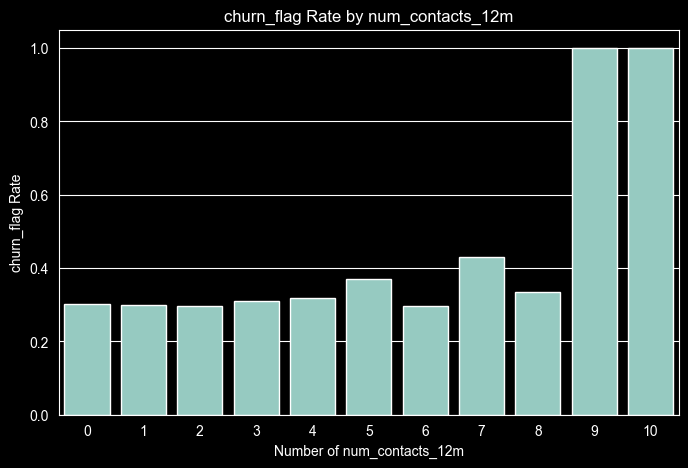

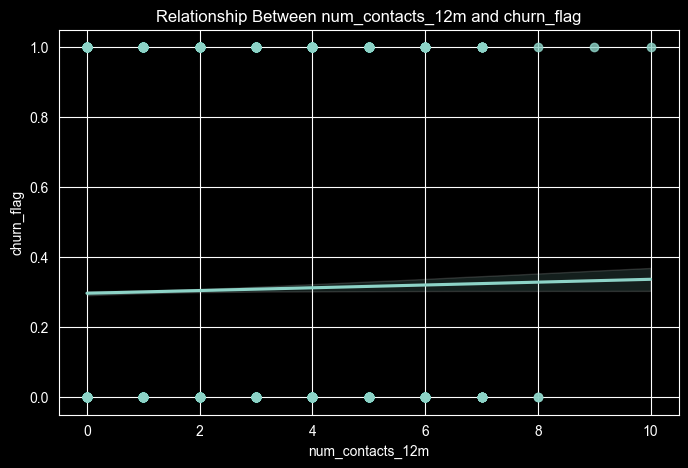

In [35]:
support_churn = df.groupby('num_contacts_12m')['churn_flag'].mean().reset_index()

# barplot이 관계를 보기 가장 좋다.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
data=support_churn,
x='num_contacts_12m',
y='churn_flag'
)

plt.title("churn_flag Rate by num_contacts_12m")
plt.xlabel("Number of num_contacts_12m")
plt.ylabel("churn_flag Rate")

plt.show()

plt.figure(figsize=(8,5))

sns.regplot(
data=df,
x='num_contacts_12m',
y='churn_flag',
logistic=True
)

plt.title("Relationship Between num_contacts_12m and churn_flag")

plt.show()

# 설명  num_contacts_12m

logistic=True